In [1]:
# =========================================================
# BLOCO 1 — IMPORTAÇÃO DE BIBLIOTECAS
# =========================================================

import os  # Manipulação de diretórios e arquivos do sistema operacional
import pandas as pd  # Manipulação e análise de dados via DataFrame
import numpy as np  # Operações numéricas e vetoriais
import matplotlib.pyplot as plt  # Geração de gráficos
import sys  # Controle de execução do sistema (ex: sys.exit)

# =========================================================
# BLOCO 2 — DEFINIÇÃO DE CONSTANTES FÍSICAS E PARÂMETROS
# =========================================================

n = 1  # Coeficiente associado à velocidade de grupo
g = 9.81  # Aceleração da gravidade (m/s²)
rho = 1025  # Densidade da água do mar (kg/m³)
posicao_segundo_ponto = 80  # Distância-alvo para seleção do segundo ponto no perfil (m), ocorre antes do ponto de máxima velocidade

# =========================================================
# BLOCO 3 — CONFIGURAÇÃO INICIAL
# =========================================================

pasta_altura = "C:\\Diretorio Delft3D\\Jacone\\Resultados\\Altura"  # Diretório contendo os arquivos CSV de altura
resultados = []  # Lista para armazenar os resultados processados de cada arquivo
recorde_velocidade = 0  # Variável de controle para registrar a maior velocidade encontrada globalmente
estilo_de_fonte = {'fontsize':15, 'color': "#000000", 'family': 'times new roman'}  # Configurações de estilo para os rótulos dos gráficos


In [2]:
# =========================================================
# BLOCO PRINCIPAL — PROCESSAMENTO DOS ARQUIVOS DE ALTURA
# =========================================================

for arquivo in os.listdir(pasta_altura):
    # Itera sobre todos os arquivos contidos no diretório de altura

    if not arquivo.endswith(".csv"):
        # Ignora arquivos que não sejam CSV
        continue

    # -----------------------------------------------------
    # 1. LEITURA E PRÉ-PROCESSAMENTO — ARQUIVO DE ALTURA
    # -----------------------------------------------------

    caminho_arquivo = os.path.join(pasta_altura, arquivo)
    # Monta o caminho absoluto do arquivo

    df = pd.read_csv(caminho_arquivo, sep=";", header=0)
    # Lê o CSV utilizando ponto e vírgula como separador

    df['altura_media'] = (df.iloc[2:, 2:5].apply(pd.to_numeric, errors="coerce").mean(axis=1))
    # Calcula a média das colunas 2 a 4 (a partir da linha 2),
    # convertendo previamente para numérico

    df["x coordinate"] = pd.to_numeric(df["x coordinate"], errors="coerce")
    df["y coordinate"] = pd.to_numeric(df["y coordinate"], errors="coerce")
    # Garante que as coordenadas estejam em formato numérico

    # -----------------------------------------------------
    # 2. CENTRALIZAÇÃO DAS COORDENADAS — ALTURA
    # -----------------------------------------------------

    primeiro_valorX = df["x coordinate"].iloc[1]
    primeiro_valorY = df["y coordinate"].iloc[1]
    # Define ponto de referência (segunda linha do DataFrame)

    x_coordinate_h = df["x coordinate"] - primeiro_valorX
    y_coordinate_h = df["y coordinate"] - primeiro_valorY
    # Translada o sistema de coordenadas para origem local

    df['comprimento_sessao_h'] = (x_coordinate_h**2 + y_coordinate_h**2) ** 0.5
    # Calcula a distância euclidiana ao ponto de referência

    # -----------------------------------------------------
    # 3. DEFINIÇÃO DO ÂNGULO (α) E ARQUIVO DE VELOCIDADE
    # -----------------------------------------------------

    pasta_velocidade = r"C:\\Diretorio Delft3D\\Jacone\\Resultados\\Velocidade"
    # Diretório onde estão armazenados os arquivos de velocidade

    nome_base = arquivo[4:]
    # Remove os quatro primeiros caracteres do nome original

    if arquivo.startswith("O"):
        alpha = 0.2618  # rad
        nome_arquivo_vel = "O_V_" + nome_base

    elif arquivo.startswith("C"):
        alpha = 0.1222  # rad
        nome_arquivo_vel = "C_V_" + nome_base

    elif arquivo.startswith("L"):
        alpha = 0.1396  # rad
        nome_arquivo_vel = "L_V_" + nome_base

    else:
        sys.exit("Arquivo com nome inválido para determinar o ângulo alpha.")
        # Interrompe execução se o padrão de nomenclatura não for reconhecido

    # -----------------------------------------------------
    # 4. LEITURA E PRÉ-PROCESSAMENTO — VELOCIDADE
    # -----------------------------------------------------

    caminho_arquivo_vel = os.path.join(pasta_velocidade, nome_arquivo_vel)
    # Caminho completo do arquivo de velocidade correspondente

    df2 = pd.read_csv(caminho_arquivo_vel,sep=";",header=0,encoding="latin1")
    # Lê o arquivo de velocidade

    df2["velocidade"] = (df.iloc[2:, 2:5].apply(pd.to_numeric, errors="coerce").mean(axis=1))
    # Calcula média das colunas de interesse (mesma lógica aplicada anteriormente)

    df2["x coordinate"] = pd.to_numeric(df2["x coordinate"], errors="coerce")
    df2["y coordinate"] = pd.to_numeric(df2["y coordinate"], errors="coerce")
    # Converte coordenadas para tipo numérico

    # -----------------------------------------------------
    # 5. IDENTIFICAÇÃO DOS VALORES MÁXIMOS
    # -----------------------------------------------------

    max_velocidade_temporaria = df2["velocidade"].max()
    # Obtém a velocidade máxima do arquivo atual

    if max_velocidade_temporaria > recorde_velocidade:
        recorde_velocidade = max_velocidade_temporaria
    # Atualiza o recorde global, se necessário

    max_velocidade = max_velocidade_temporaria / recorde_velocidade
    # Normaliza a velocidade máxima pelo recorde global

    df_primeira_metade_perfil = df.iloc[:len(df)//2]
    # Seleciona a primeira metade do perfil de altura

    idx_Hs_max = df_primeira_metade_perfil["altura_media"].idxmax()
    # Índice da maior altura significativa nessa metade

    Hs = df_primeira_metade_perfil.loc[idx_Hs_max]["altura_media"]
    x = df_primeira_metade_perfil.loc[idx_Hs_max]["comprimento_sessao_h"]
    # Extrai Hs máximo e sua posição correspondente
    # -----------------------------------------------------
    # 6. CÁLCULO DA TENSÃO DE RADIAÇÃO (Sxy)
    # -----------------------------------------------------

    def tensao_radiacao(Hs, n, alpha):
        # Calcula componente Sxy da tensão de radiação

        E = (1/8) * rho * g * Hs**2
        # Energia da onda (teoria linear)

        return E * n * np.sin(alpha) * np.cos(alpha)
        # Componente tangencial da tensão de radiação

    Sxy = tensao_radiacao(Hs, n, alpha)
    # Tensão no ponto de Hs máximo

    # -----------------------------------------------------
    # 7. SELEÇÃO DE SEGUNDO PONTO
    # -----------------------------------------------------

    df['selecionar_extensao'] = ((df['comprimento_sessao_h'] - posicao_segundo_ponto).abs())
    # Calcula a distância absoluta ao ponto desejado

    df['extensao_selecionada'] = df['selecionar_extensao'].idxmin()
    # Obtém o índice mais próximo da distância alvo
    
    extensao_selecionada = df['extensao_selecionada'].iloc[0]
    linha_selecionada = df.iloc[extensao_selecionada]
    # Seleciona a linha correspondente

    Hs2 = linha_selecionada["altura_media"]
    x2 = linha_selecionada["comprimento_sessao_h"]
    # Extrai Hs e posição do segundo ponto

    Sxy2 = tensao_radiacao(Hs2, n, alpha)
    # Calcula tensão no segundo ponto

    # -----------------------------------------------------
    # 8. TAXA DE VARIAÇÃO ESPACIAL
    # -----------------------------------------------------

    variacao_bruta = (Sxy - Sxy2) / (x - x2)
    
    # Gradiente espacial discreto de Sxy

    # -----------------------------------------------------
    # 9. ARMAZENAMENTO DOS RESULTADOS
    # -----------------------------------------------------

    resultados.append({
        "arquivo": arquivo,
        "variacao_bruta": variacao_bruta,
        "max_velocidade": max_velocidade
    })
    # Armazena resultados parciais do arquivo processado



# =========================================================
# BLOCO FINAL — CONSOLIDAÇÃO DOS RESULTADOS
# =========================================================

df_resultados = pd.DataFrame(resultados)
# Converte lista de dicionários em DataFrame

# -----------------------------------------------------
# FILTRAGEM POR TIPO DE CASO
# -----------------------------------------------------

df_O = df_resultados[df_resultados["arquivo"].str.startswith("O")]
df_C = df_resultados[df_resultados["arquivo"].str.startswith("C")]
df_L = df_resultados[df_resultados["arquivo"].str.startswith("L")]
# Segmenta os resultados conforme prefixo do arquivo

def normalizar_variacao(df_O):
    # Função para normalizar a variação bruta dentro de um DataFrame específico
    max_variacao_bruta = df_O["variacao_bruta"].max()
    # Determina valor máximo da variação bruta
    df_O["variacao_normalizada"] = (df_O["variacao_bruta"] / max_variacao_bruta)
    return df_O
dsxy_O= normalizar_variacao(df_O)
dsxy_C= normalizar_variacao(df_C)
dsxy_L= normalizar_variacao(df_L)

df_resultados = pd.concat([dsxy_O, dsxy_C, dsxy_L], ignore_index=True)


C:\Users\Ricardo\AppData\Local\Temp\ipykernel_24424\205392509.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_O["variacao_normalizada"] = (df_O["variacao_bruta"] / max_variacao_bruta)
C:\Users\Ricardo\AppData\Local\Temp\ipykernel_24424\205392509.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_O["variacao_normalizada"] = (df_O["variacao_bruta"] / max_variacao_bruta)
C:\Users\Ricardo\AppData\Local\Temp\ipykernel_24424\205392509.py:189: SettingWithCopyWarning: 
A value is trying to be set on 

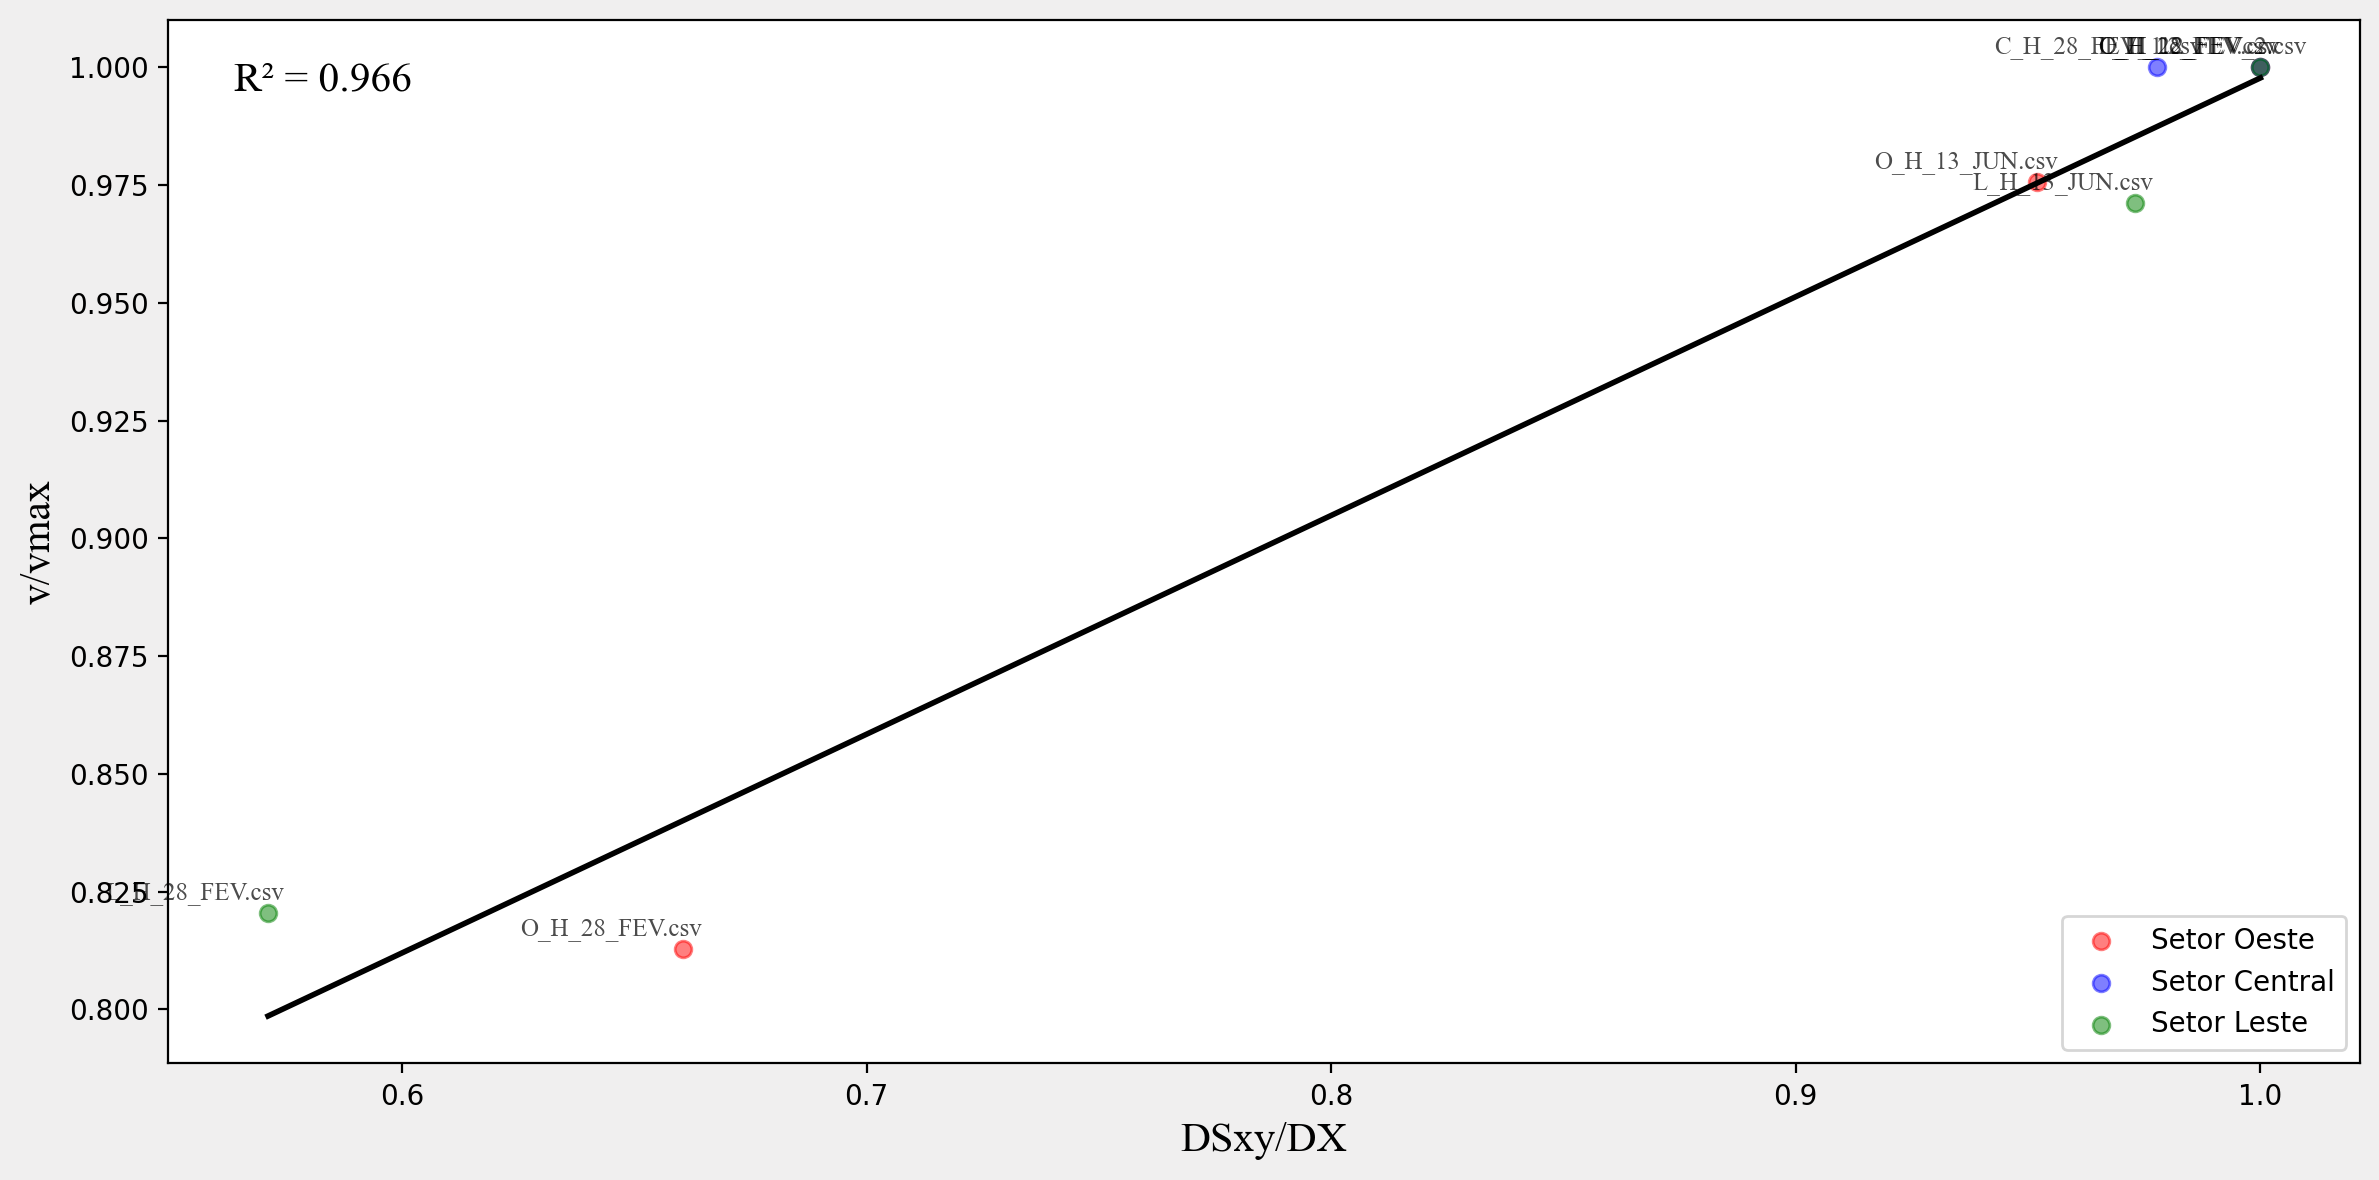

In [3]:
# =========================================================
# BLOCO DE VISUALIZAÇÃO — DISPERSÃO E REGRESSÃO LINEAR
# =========================================================

plt.figure(figsize=(12,6), dpi=200, facecolor="#F0EFEFFF")  # Cria a figura com dimensão 12x6 e DPI de 100

# ---------------------------------------------------------
# 1. DISPERSÃO POR SETOR
# ---------------------------------------------------------

plt.scatter(np.abs(df_O["variacao_normalizada"]), df_O["max_velocidade"], label="Setor Oeste", color="red", alpha=0.5)# Setor Oeste: |variação| vs velocidade normalizada
plt.scatter(np.abs(df_C["variacao_normalizada"]), df_C["max_velocidade"], label="Setor Central", color="blue", alpha=0.5)  # Setor Central
plt.scatter(np.abs(df_L["variacao_normalizada"]), df_L["max_velocidade"], label="Setor Leste", color="green", alpha=0.5)  # Setor Leste

def rotular_pontos(df):
    for i in range(len(df)):
        # x = Variação Normalizada, y = Velocidade Máxima
        x = np.abs(df["variacao_normalizada"].iloc[i])
        y = df["max_velocidade"].iloc[i]
        nome = df["arquivo"].iloc[i]
        
        # Adiciona o texto levemente deslocado para não ficar em cima do ponto
        plt.text(x - 0.035, y + 0.003, nome, fontsize = 9, alpha = 0.7,fontdict=estilo_de_fonte)

# Chama a função para cada setor
rotular_pontos(df_O)
rotular_pontos(df_C)
rotular_pontos(df_L)
# ---------------------------------------------------------
# 2. REGRESSÃO LINEAR GLOBAL
# ---------------------------------------------------------

y_clean = df_resultados["max_velocidade"].astype(float)  # Converte variável dependente para float
x_clean = np.abs(df_resultados["variacao_normalizada"].astype(float))  # Converte variável independente para float e aplica módulo
mask = np.isfinite(x_clean) & np.isfinite(y_clean)  # Remove valores inválidos (NaN ou infinitos)

coef = np.polyfit(x_clean[mask], y_clean[mask], 1)  # Ajuste linear (y = ax + b)
tendencia = np.poly1d(coef)  # Constrói função polinomial do ajuste
x_vals = np.linspace(x_clean[mask].min(), x_clean[mask].max(), 100)  # Gera 100 pontos no intervalo observado
plt.plot(x_vals, tendencia(x_vals), color="black", linewidth=2)  # Plota linha de tendência

# ---------------------------------------------------------
# 3. CÁLCULO DO R²
# ---------------------------------------------------------

y_pred = tendencia(x_clean[mask])  # Valores previstos pelo modelo
ss_res = np.sum((y_clean[mask] - y_pred)**2)  # Soma dos quadrados dos resíduos
ss_tot = np.sum((y_clean[mask].to_numpy() - np.mean(y_clean[mask].to_numpy()))**2)  # Soma total dos quadrados
r1 = 1 - (ss_res / ss_tot)  # Coeficiente de determinação

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO FINAL DO GRÁFICO
# ---------------------------------------------------------

plt.xlabel("DSxy/DX", estilo_de_fonte)  # Rótulo eixo x
plt.ylabel("v/vmax", estilo_de_fonte)  # Rótulo dsdsdsdseixo y
plt.title("", estilo_de_fonte)  # Título mantido vazio
plt.legend(fontsize=10)  # Exibe legenda com tamanho de fonte ajustado
plt.tight_layout()  # Ajusta layout
plt.text(0.03, 0.96, f"R² = {r1:.3f}", transform=plt.gca().transAxes, fontdict=estilo_de_fonte, verticalalignment="top")  # Insere R² no gráfico
plt.show()  # Exibe figura
